# Traffic Collision Data Analysis

# Objective

In this case study, you will be working on California Traffic Collision Data Analysis using Apache Spark, a powerful distributed computing framework designed for big data processing. This assignment aims to provide hands-on experience in analyzing large-scale traffic collision datasets using PySpark and AWS services. You will apply data analytics techniques to clean, transform, and explore crash data, drawing meaningful insights to support traffic safety and urban planning. Beyond understanding how big data tools optimize performance on a single machine and across clusters, you will develop a structured approach to analyzing crash trends, identifying high-risk locations, and evaluating contributing factors to traffic incidents. Additionally, you will utilize AWS S3 to store the processed data efficiently after the ETL process, enabling scalable storage and easy retrieval for further analysis.


# Business Value:

Traffic collisions pose significant risks to public safety, requiring continuous monitoring and analysis to enhance road safety measures. Government agencies, city planners, and policymakers must leverage data-driven insights to improve infrastructure, optimize traffic management, and implement preventive measures.

In this assignment, you will analyze California traffic collision data to uncover patterns related to accident severity, location-based risks, and key contributing factors. With Apache Spark's ability to handle large datasets efficiently and AWS S3's scalable storage, transportation authorities can process vast amounts of crash data in real time, enabling faster and more informed decision-making.

As an analyst examining traffic safety trends, your task is to analyze historical crash data to derive actionable insights that can drive policy improvements and safety interventions. Your analysis will help identify high-risk areas, categorize accidents by severity and contributing factors, and store the processed data in an AWS S3 bucket for scalable and long-term storage.

By leveraging big data analytics and cloud-based storage, urban planners and traffic authorities can enhance road safety strategies, reduce accident rates, and improve public transportation planning.


# Dataset Overview

The dataset used in this analysis consists of California traffic collision data obtained from the Statewide Integrated Traffic Records System (SWITRS). It includes detailed records of traffic incidents across California, covering various attributes such as location, severity, involved parties, and contributing factors. The dataset has been preprocessed and transformed using PySpark to facilitate large-scale analysis. By leveraging Apache Spark, we ensure efficient data handling, enabling deeper insights into traffic patterns, accident trends, and potential safety improvements.

The dataset is a .sqlite file contains detailed information about traffic collisions across California and is structured into four primary tables:
- `collisions` table contains information about the collision, where it happened, what vehicles were involved.

- `parties` table contains information about the groups people involved in the collision including age, sex, and sobriety.

- `victims` table contains information about the injuries of specific people involved in the collision.

- `locations` table contains information about the geographical location and details of road intersections.

# Assignment Tasks

<ol>
    <li>
        <strong>Data Preparation</strong></br>
        The dataset consists of structured tables containing traffic collision data. Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.</br>
        Check for data consistency and ensure all columns are correctly formatted.</br>
        Apply sampling techniques if needed to extract a representative subset for analysis.</br>
        Structure and prepare the data for further processing and analysis.</br>
    </br>
    <li>
        <strong>Data Cleaning</strong></br>
            2.1 <strong>Fixing Columns:</strong> Ensure all columns are properly named and formatted.</br>
            2.2 <strong>Handling Missing Values:</strong> Decide on an approach to handle missing data (e.g., imputation or removal). Mention the approach in your report.</br>
            2.3 <strong>Handling Outliers:</strong> Identify outliers in the dataset and explain why they are considered outliers. It is not necessary to remove them for this task, but mention your approach for handling them.</br>
    </br>
    <li>
        <strong>Exploratory Data Analysis</strong></br>
        Finding Patterns and analyze the dataset and find patterns based on the following points:
                <ul>
                3.1 Classify variables into categorical and numerical types.</br>
                3.2 Analyze the distribution of collision severity.</br>
                3.3 Examine weather conditions during collisions.</br>
                3.4 Analyze the distribution of victim ages.</br>
                3.5 Study the relationship between collision severity and the number of victims.</br>
                3.6 Analyze the correlation between weather conditions and collision severity.</br>
                3.7 Visualize the impact of lighting conditions on collision severity.</br>
                3.8 Extract and analyze weekday-wise collision trends.</br>
                3.9 Assess the number of collisions occurring on different days of the week.</br>
                3.10 Study spatial distribution of collisions by county.</br>
                3.11 Generate a scatter plot to analyze collision locations geographically.</br>
                3.12 Extract and analyze collision trends over time, including yearly, monthly, and hourly trends.</br>
</ul>
</br>
<li>
<strong>ETL Querying</strong><br>
Write PySpark SQL queries for the following:</br>
<ol>
    4.1. Load the processed dataset as CSV files in S3 bucket.</br>
    4.2. Identify the top 5 counties with the highest number of collisions.</br>
    4.3. Identify the month with the highest number of collisions.</br>
    4.4. Determine the most common weather condition during collisions.</br>
    4.5. Calculate the percentage of collisions that resulted in fatalities.</br>
    4.6. Find the most dangerous time of day for collisions.</br>
    4.7. Identify the top 5 road surface conditions with the highest collision frequency.</br>
    4.8. Analyze lighting conditions that contribute to the highest number of collisions.</br>
</ol>
</br>
<li>
<strong>Conclusion</strong></br>
Provide final insights and recommendations based on the analysis:
    <ul>
        5.1 Recommendations to improve road safety by identifying high-risk locations and peak accident times for infrastructure improvements.</br>
        5.2 Suggestions to optimize traffic management by analyzing trends in collision severity, weather conditions, and lighting to improve road design and traffic signal timing.</br>
        5.3 Propose data-driven policy changes to enhance pedestrian and cyclist safety based on collision trends involving vulnerable road users.</br>
        5.4 Identify potential high-risk zones for proactive intervention by examining geographic collision density and historical accident data.</br>
        5.5 Assess the impact of environmental factors such as weather, road surface conditions, and lighting on accident frequency and severity.</br>
        5.6 Develop predictive models to anticipate collision hotspots and support proactive safety measures.</br>
        </ul>
        Conclude the analysis by summarizing key findings and business implications.</br>
        Explain the results of univariate, segmented univariate, and bivariate analyses in real-world traffic safety and policy terms.</br>
        Include visualizations and summarize the most important results in the report. Insights should explain why each variable is important and how they can influence traffic safety policies and urban planning.</br>
        </ul>
        </br>
    <li>
    <strong>Visualization Integration [Optional]</strong>
    <p>Enhance the project by incorporating a visualization component that connects the processed data stored in an S3 bucket to a business intelligence tool such as Tableau or Power BI. This involves setting up the connection between the S3 bucket and the chosen visualization tool, importing the processed dataset for analysis and visualization, creating interactive dashboards to explore key trends and insights and ensuring data updates are reflected dynamically in the visualization tool.<br>
</br>
</ol>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Install Required Libraries

In [ ]:
## Install the required libraries
!pip install --quiet pyspark==4.0.0 pandas==2.2.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.1/434.1 MB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# Import the necessary libraries
import sqlite3
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, to_date, count, countDistinct, trim, lower

# Initialize SparkSession
spark = SparkSession.builder.appName("TrafficCollisionAnalysis").getOrCreate()

#**1. Data Preparation** <font color = red>[5 marks]</font> <br>

The dataset consists of structured tables containing traffic collision data.

Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.

Check for data consistency and ensure all columns are correctly formatted.

In [ ]:
# Write code to load the data and check the schema
collision_df = spark.read.csv('/content/drive/MyDrive/IIITB_PySpark_Assignment/sample_collisions.csv', header=True, inferSchema=True)
collision_df.printSchema()

root
 |-- case_id: double (nullable = true)
 |-- jurisdiction: double (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: double (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: double (nullable = true)
 |-- caltrans_county: string (nullable = true)
 |-- caltrans_district: double (nullable = true)
 |-- s

In [ ]:
parties_df = spark.read.csv('/content/drive/MyDrive/IIITB_PySpark_Assignment/sample_parties.csv', header=True, inferSchema=True)
parties_df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- case_id: double (nullable = true)
 |-- party_number: integer (nullable = true)
 |-- party_type: string (nullable = true)
 |-- at_fault: integer (nullable = true)
 |-- party_sex: string (nullable = true)
 |-- party_age: double (nullable = true)
 |-- party_sobriety: string (nullable = true)
 |-- direction_of_travel: string (nullable = true)
 |-- party_safety_equipment_1: string (nullable = true)
 |-- party_safety_equipment_2: string (nullable = true)
 |-- financial_responsibility: string (nullable = true)
 |-- cellphone_in_use: double (nullable = true)
 |-- cellphone_use_type: string (nullable = true)
 |-- other_associate_factor_1: string (nullable = true)
 |-- party_number_killed: integer (nullable = true)
 |-- party_number_injured: integer (nullable = true)
 |-- movement_preceding_collision: string (nullable = true)
 |-- vehicle_year: double (nullable = true)
 |-- vehicle_make: string (nullable = true)
 |-- statewide_vehicle_type: string (nu

In [ ]:
victims_df = spark.read.csv('/content/drive/MyDrive/IIITB_PySpark_Assignment/sample_victims.csv', header=True, inferSchema=True)
victims_df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- case_id: double (nullable = true)
 |-- party_number: integer (nullable = true)
 |-- victim_role: string (nullable = true)
 |-- victim_sex: string (nullable = true)
 |-- victim_age: double (nullable = true)
 |-- victim_degree_of_injury: string (nullable = true)
 |-- victim_seating_position: string (nullable = true)
 |-- victim_safety_equipment_1: string (nullable = true)
 |-- victim_safety_equipment_2: string (nullable = true)
 |-- victim_ejected: string (nullable = true)



In [ ]:
case_ids_df = spark.read.csv('/content/drive/MyDrive/IIITB_PySpark_Assignment/sample_case_ids.csv', header=True, inferSchema=True)
case_ids_df.printSchema()

root
 |-- case_id: double (nullable = true)
 |-- db_year: integer (nullable = true)



#**2. Data Cleaning** <font color = red>[20 marks]</font> <br>


In [ ]:
#Display Schema & Sample Data
collision_df.show(5)

+-----------+------------+----------+------------------+--------------+----------------+--------------------+---------------+-----------------+-------------------+----------------+--------------+-----------+------------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+--------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+---------------+-----------------+---------------------------+--------------------+------------+----------------+--------------------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+---

In [ ]:
parties_df.show()

+--------+--------------------+------------+--------------+--------+---------+---------+--------------------+-------------------+------------------------+------------------------+------------------------+----------------+--------------------+------------------------+-------------------+--------------------+----------------------------+------------+------------+----------------------+-----------------------+----------------------+----------+
|      id|             case_id|party_number|    party_type|at_fault|party_sex|party_age|      party_sobriety|direction_of_travel|party_safety_equipment_1|party_safety_equipment_2|financial_responsibility|cellphone_in_use|  cellphone_use_type|other_associate_factor_1|party_number_killed|party_number_injured|movement_preceding_collision|vehicle_year|vehicle_make|statewide_vehicle_type|chp_vehicle_type_towing|chp_vehicle_type_towed|party_race|
+--------+--------------------+------------+--------------+--------+---------+---------+--------------------+-

In [ ]:
victims_df.show()

+-------+--------------------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|     id|             case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+-------+--------------------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|2166324|           6324923.0|           1|     driver|      male|      62.0|      complaint of pain|                 driver|     air bag not deployed|     lap/shoulder harn...|   not ejected|
| 779470|            761473.0|           1|  passenger|      male|      25.0|              no injury|       passenger seat 3|     lap/shoulder harn...|                     NULL|   not ejected|
| 742636|            723123.0|     

In [ ]:
case_ids_df.show()

+-----------+-------+
|    case_id|db_year|
+-----------+-------+
|9.0017156E7|   2021|
|  4078685.0|   2021|
|9.0588783E7|   2021|
|  3351919.0|   2018|
|   632208.0|   2018|
|  2465363.0|   2018|
|  6440794.0|   2021|
|  3659930.0|   2020|
|  1562201.0|   2018|
|9.0762102E7|   2021|
|9.1440312E7|   2021|
|  2142550.0|   2018|
|9.1142539E7|   2021|
|   443135.0|   2018|
|  4048062.0|   2020|
|9.0118537E7|   2021|
|  6847037.0|   2021|
|9.0097757E7|   2021|
|   718581.0|   2018|
|  6603715.0|   2021|
+-----------+-------+
only showing top 20 rows


##**2.1 Missing Values** <font color = red>[10 marks]</font> <br>


In [ ]:
from pyspark.sql.functions import col, when, trim, lower
from pyspark.sql.types import StringType

FAKE_NULLS = ["null", "na", "none", ""]

def normalize_string_nulls(df):
    for c, dtype in df.dtypes:
      df = df.withColumn(
          c,
          when(
              lower(trim(col(c))).isin(FAKE_NULLS),
              None
          ).otherwise(col(c))
      )
    return df
normalize_string_nulls(collision_df)
normalize_string_nulls(victims_df)
normalize_string_nulls(parties_df)
normalize_string_nulls(case_ids_df)

DataFrame[case_id: double, jurisdiction: double, officer_id: string, reporting_district: string, chp_shift: string, population: string, county_city_location: int, county_location: string, special_condition: double, beat_type: string, chp_beat_type: string, chp_beat_class: string, beat_number: string, primary_road: string, secondary_road: string, distance: double, direction: string, intersection: double, weather_1: string, state_highway_indicator: double, caltrans_county: string, caltrans_district: double, state_route: double, postmile: double, location_type: string, side_of_highway: string, tow_away: double, collision_severity: string, killed_victims: double, injured_victims: double, party_count: double, primary_collision_factor: string, pcf_violation_category: string, pcf_violation: double, pcf_violation_subsection: string, hit_and_run: string, type_of_collision: string, motor_vehicle_involved_with: string, pedestrian_action: string, road_surface: string, road_condition_1: string, lig

In [ ]:
# Check for Missing Values
# Displaying only columns that have missing values to reduce clutter

from pyspark.sql.functions import sum as spark_sum, round

def null_percentage(df, df_name="df"):
    df = normalize_string_nulls(df)
    total_rows = df.count()

    null_df = df.select([
        round(
            (spark_sum(col(c).isNull().cast("int")) / total_rows) * 100, 2
        ).alias(c)
        for c in df.columns
    ])

    result = (
        null_df.selectExpr(
            "stack({}, {}) as (column_name, null_percentage)".format(
                len(df.columns),
                ",".join([f"'{c}', {c}" for c in df.columns])
            )
        )
        .filter(col("null_percentage") > 0)
        .orderBy(col("null_percentage").desc())
    )

    print(f"\n📊 Null Percentage Report for `{df_name}` (real + string NULLs)")
    result.show(truncate=False)

null_percentage(collision_df, "collision_df")
null_percentage(case_ids_df, "case_ids_df")
null_percentage(victims_df, "victims_df")
null_percentage(parties_df, "parties_df")




📊 Null Percentage Report for `collision_df` (real + string NULLs)
+-------------------------------+---------------+
|column_name                    |null_percentage|
+-------------------------------+---------------+
|caltrans_county                |72.89          |
|location_type                  |72.89          |
|side_of_highway                |72.89          |
|latitude                       |71.5           |
|longitude                      |71.5           |
|caltrans_district              |69.32          |
|state_route                    |69.32          |
|postmile                       |69.32          |
|control_device                 |66.68          |
|pcf_violation_subsection       |64.27          |
|reporting_district             |59.06          |
|chp_vehicle_type_at_fault      |26.89          |
|direction                      |24.86          |
|statewide_vehicle_type_at_fault|19.89          |
|beat_number                    |8.63           |
|pcf_violation                  |

In [ ]:
#Drop Sparse Columns


In [ ]:
#Convert Data Types

victims_df = victims_df.withColumn("victim_age", col("victim_age").cast("int"))

In [ ]:
#Handle Missing Values
victims_df = victims_df.na.drop(subset=["victim_age"])

##**2.2 Fixing Columns** <font color = red>[5 marks]</font> <br>


In [ ]:
#Remove Duplicates
def remove_duplicates(df):
    return df.dropDuplicates()

collision_df = remove_duplicates(collision_df)
case_ids_df = remove_duplicates(case_ids_df)
victims_df = remove_duplicates(victims_df)
parties_df = remove_duplicates(parties_df)

##**2.3 Outlier Analysis** <font color = red>[5 marks]</font> <br>


In [ ]:
import pyspark.sql.functions as F

def detect_iqr_outliers_single_column(df, column_name, df_name="df"):
    # Cast + remove nulls
    df_clean = (
        df
        .withColumn(column_name, F.col(column_name).cast("int"))
        .filter(F.col(column_name).isNotNull())
    )

    total_rows = df_clean.count()

    # Compute quantiles
    quantiles = df_clean.approxQuantile(column_name, [0.25, 0.75], 0.01)

    if len(quantiles) != 2:
        print(f"No valid quantiles for `{column_name}` in `{df_name}`")
        return None

    q1, q3 = quantiles

    if q1 == q3:
        print(f"Flat distribution for `{column_name}` in `{df_name}`")
        return None

    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers_df = df_clean.filter(
        (F.col(column_name) < lower) | (F.col(column_name) > upper)
    )

    outlier_count = outliers_df.count()
    pct = round((outlier_count / total_rows) * 100, 2)

    print(f"\n📊 IQR Outlier Report — `{df_name}.{column_name}`")
    print(f"Rows checked: {total_rows}")
    print(f"Lower bound: {round(lower,2)}")
    print(f"Upper bound: {round(upper,2)}")
    print(f"Outliers: {outlier_count} ({pct}%)")

    return outliers_df


victim_age_outliers = detect_iqr_outliers_single_column(
    victims_df,
    column_name="victim_age",
    df_name="victims_df"
)



📊 IQR Outlier Report — `victims_df.victim_age`
Rows checked: 931788
Lower bound: -22.5
Upper bound: 85.5
Outliers: 4598 (0.49%)


In [ ]:
victims_df.count()

963933

In [ ]:
#Remove Outliers
victims_df = victims_df.filter(col("victim_age").between(0, 100))

In [ ]:
victims_df.count()

931655

#**3. Exploratory Data Analysis** <font color = red>[65 marks]</font> <br>


##**3.1.1. Data Preparation** <font color = red>[5 marks]</font> <br>

Q: Classify variables into categorical and numerical.

Categorical Variables -
officer_id
reporting_district
chp_shift
population
county_location
beat_type
chp_beat_type
chp_beat_class
beat_number
primary_road
secondary_road
direction
weather_1
caltrans_county
location_type
side_of_highway
collision_severity
primary_collision_factor
pcf_violation_category
pcf_violation_subsection
hit_and_run
type_of_collision
motor_vehicle_involved_with
pedestrian_action
road_surface
road_condition_1
lighting
control_device
statewide_vehicle_type_at_fault
chp_vehicle_type_at_fault


Numerical Variables - case_id
jurisdiction
county_city_location
special_condition
distance
intersection
state_highway_indicator
caltrans_district
state_route
postmile
tow_away
killed_victims
injured_victims
party_count
pcf_violation
chp_road_type
pedestrian_collision
bicycle_collision
motorcycle_collision
truck_collision
not_private_property
severe_injury_count
other_visible_injury_count
complaint_of_pain_injury_count
pedestrian_killed_count
pedestrian_injured_count
bicyclist_killed_count
bicyclist_injured_count
motorcyclist_killed_count
motorcyclist_injured_count
latitude
longitude


In [ ]:
# Encode Categorical Variables
from pyspark.ml.feature import StringIndexer
categorical_cols = [
    "officer_id",
    "reporting_district",
    "chp_shift",
    "population",
    "county_location",
    "beat_type",
    "chp_beat_type",
    "chp_beat_class",
    "beat_number",
    "primary_road",
    "secondary_road",
    "direction",
    "weather_1",
    "caltrans_county",
    "location_type",
    "side_of_highway",
    "collision_severity",
    "primary_collision_factor",
    "pcf_violation_category",
    "pcf_violation_subsection",
    "hit_and_run",
    "type_of_collision",
    "motor_vehicle_involved_with",
    "pedestrian_action",
    "road_surface",
    "road_condition_1",
    "lighting",
    "control_device",
    "statewide_vehicle_type_at_fault",
    "chp_vehicle_type_at_fault"
]

# String Indexing for Categorical Columns
indexed_df = collision_df
indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=f"{col}_idx",
        handleInvalid="keep"
    )
    for col in categorical_cols
]
for indexer in indexers:
    indexed_df = indexer.fit(indexed_df).transform(indexed_df)

In [ ]:
# Final cleaned data
from pyspark.sql.functions import col, year, month, hour, to_timestamp
base_df = (
    collision_df
    .withColumn("collision_ts", to_timestamp(col("collision_time")))
    .filter(col("collision_ts").isNotNull())
)

temporal_df = (
    base_df
    .select(
        "case_id",
        year("collision_ts").alias("year"),
        month("collision_ts").alias("month"),
        hour("collision_ts").alias("hour")
    )
    .dropna()
)

spatial_df = (
    base_df
    .select(
        "case_id",
        "county_location",
        "latitude",
        "longitude"
    )
    .filter(
        col("latitude").isNotNull() &
        col("longitude").isNotNull()
    )
)

weather_severity_df = (
    base_df
    .select(
        "case_id",
        "weather_1",
        "collision_severity"
    )
    .filter(
        col("weather_1").isNotNull() &
        col("collision_severity").isNotNull()
    )
)

lighting_df = (
    base_df
    .select(
        "case_id",
        "lighting",
        "collision_severity"
    )
    .filter(col("lighting").isNotNull())
)

road_type_df = (
    base_df
    .select(
        "case_id",
        "chp_road_type"
    )
    .filter(col("chp_road_type").isNotNull())
)

severity_df = (
    base_df
    .select(
        "case_id",
        "collision_severity"
    )
    .filter(col("collision_severity").isNotNull())
)


Loading the Final Cleaned Dataset into S3 Bucket

##**3.1.2. Analyze the distribution of collision severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of collision severity.

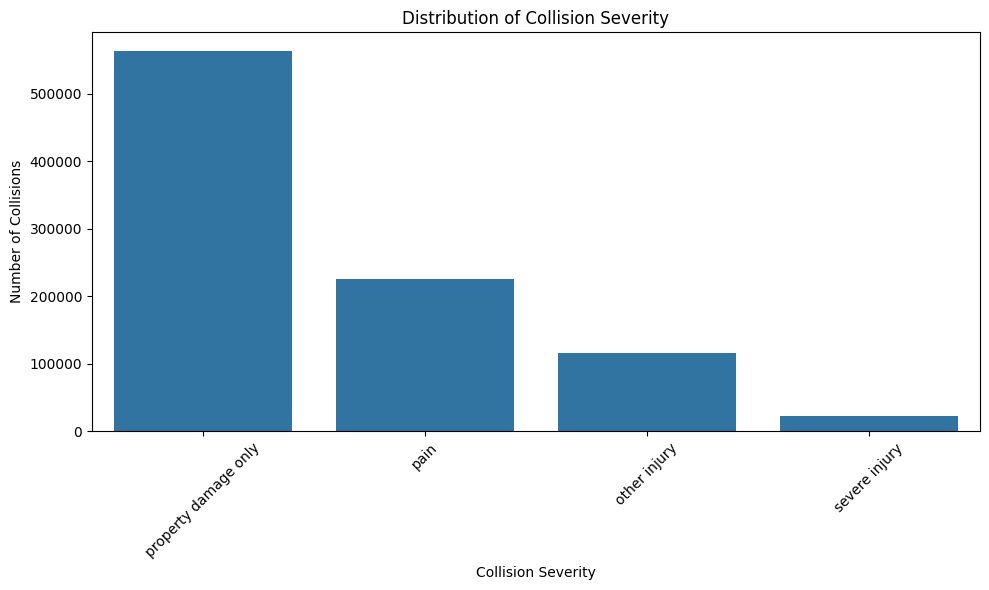

In [ ]:
# Univariate Analysis

# Collision Severity Distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Group by collision_severity and count, then order by count
severity_distribution = severity_df.groupBy('collision_severity').count().orderBy('count', ascending=False)

# Convert to Pandas for plotting
severity_distribution_pd = severity_distribution.toPandas()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='collision_severity', y='count', data=severity_distribution_pd)
plt.title('Distribution of Collision Severity')
plt.xlabel('Collision Severity')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##**3.1.3. Weather conditions during collisions.** <font color = red>[5 marks]</font> <br>

Q: Examine weather conditions during collisions.

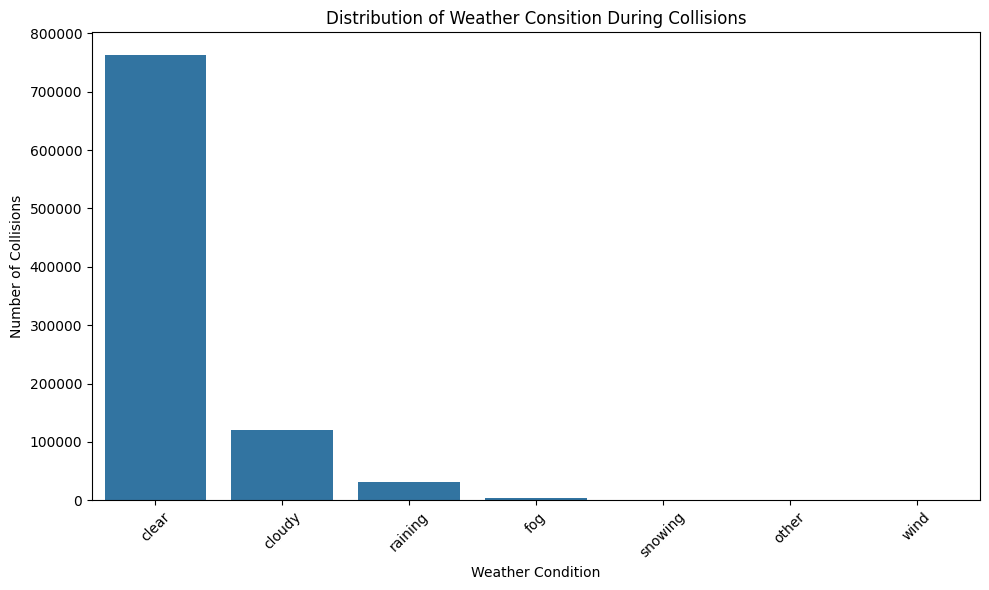

In [ ]:
# Weather Conditions During Collisions
weahter_distribution = base_df.groupBy('weather_1').count()
weahter_distribution = weahter_distribution.orderBy('count', ascending=False)
# Convert to Pandas
weahter_distribution_pd = weahter_distribution.toPandas()
# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='weather_1', y='count', data=weahter_distribution_pd)
plt.title('Distribution of Weather Condition During Collisions')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##**3.1.4. Victime Age Distribution.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of victim ages.

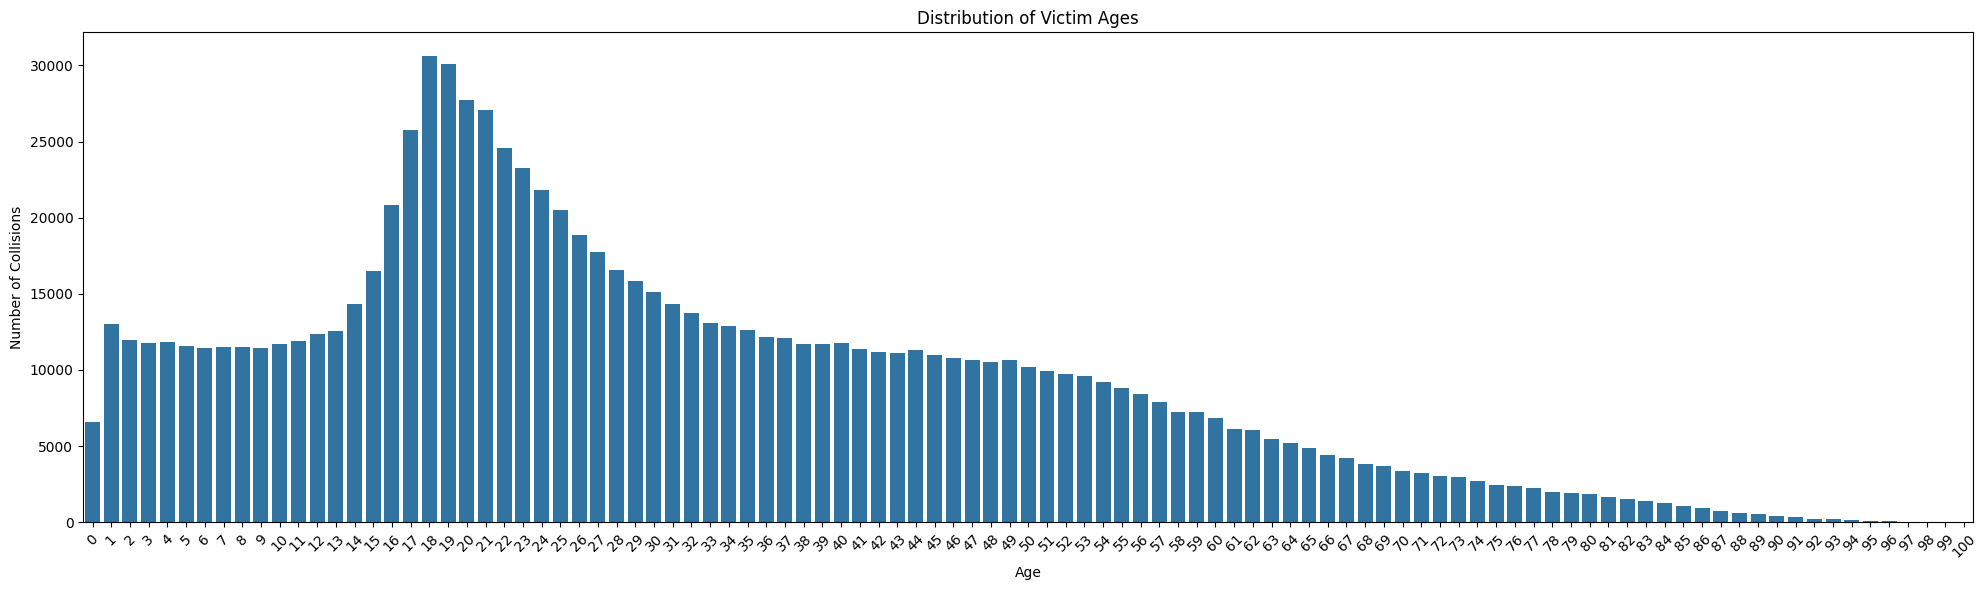

In [ ]:
# Distribution of Victim Ages
age_distribution = victims_df.groupBy('victim_age').count()
age_distribution = age_distribution.orderBy('count', ascending=False)
# Convert to Pandas
age_distribution_pd = age_distribution.toPandas()
age_distribution_pd["victim_age"] = age_distribution_pd["victim_age"].astype(int)
# Plot
plt.figure(figsize=(20, 6))
sns.barplot(x='victim_age', y='count', data=age_distribution_pd)
plt.title('Distribution of Victim Ages')
plt.xlabel('Age')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

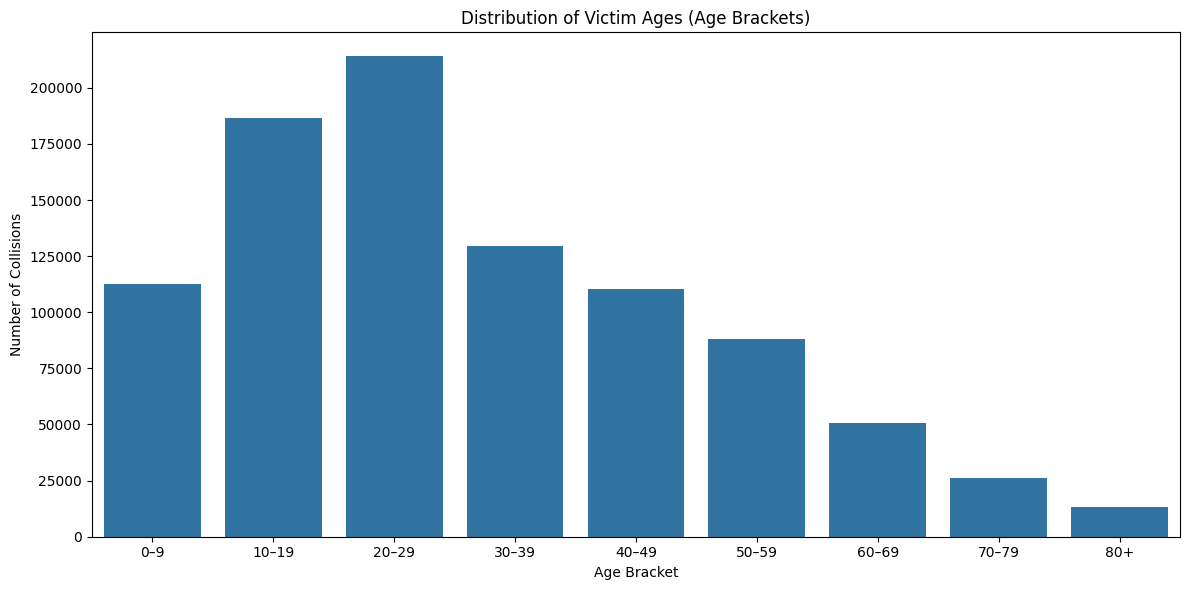

In [ ]:
from pyspark.sql.functions import col, when

victims_df_bracketed = (
    victims_df
    .withColumn("victim_age", col("victim_age").cast("int"))
    .filter(col("victim_age").isNotNull())
    .filter(col("victim_age").between(0, 100))   # remove junk like 999
    .withColumn(
        "age_bracket",
        when(col("victim_age") < 10, "0–9")
        .when(col("victim_age") < 20, "10–19")
        .when(col("victim_age") < 30, "20–29")
        .when(col("victim_age") < 40, "30–39")
        .when(col("victim_age") < 50, "40–49")
        .when(col("victim_age") < 60, "50–59")
        .when(col("victim_age") < 70, "60–69")
        .when(col("victim_age") < 80, "70–79")
        .otherwise("80+")
    )
)
age_bracket_dist = (
    victims_df_bracketed
    .groupBy("age_bracket")
    .count()
)
import pandas as pd

age_bracket_pd = age_bracket_dist.toPandas()

age_order = [
    "0–9", "10–19", "20–29", "30–39", "40–49",
    "50–59", "60–69", "70–79", "80+"
]

age_bracket_pd["age_bracket"] = pd.Categorical(
    age_bracket_pd["age_bracket"],
    categories=age_order,
    ordered=True
)

age_bracket_pd = age_bracket_pd.sort_values("age_bracket")
plt.figure(figsize=(12, 6))
sns.barplot(
    x="age_bracket",
    y="count",
    data=age_bracket_pd
)

plt.title("Distribution of Victim Ages (Age Brackets)")
plt.xlabel("Age Bracket")
plt.ylabel("Number of Collisions")
plt.tight_layout()
plt.show()


##**3.1.5. Collision Severity vs Number of Victims.** <font color = red>[5 marks]</font> <br>

Q: Study the relationship between collision severity and the number of victims.

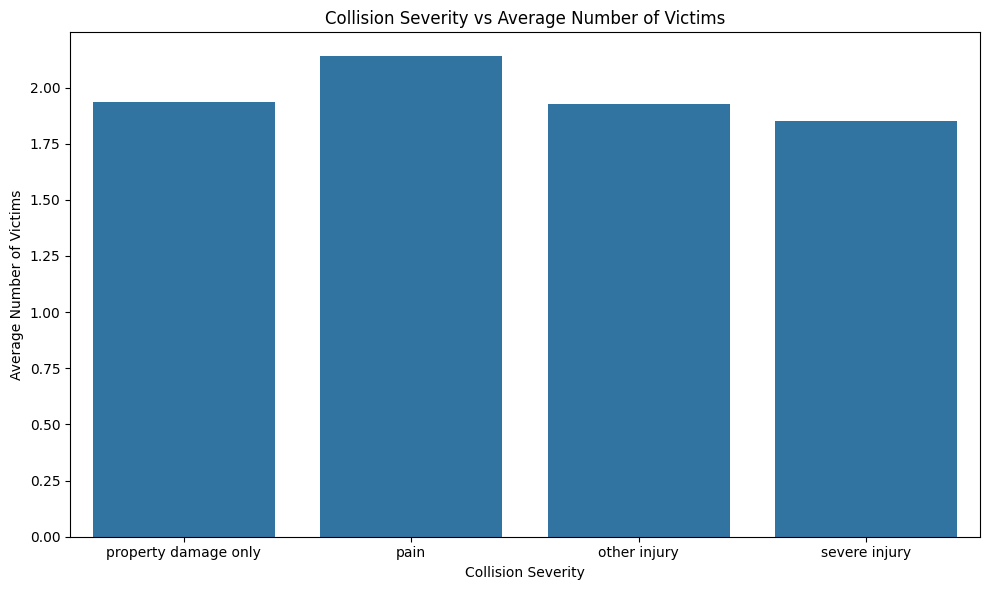

In [ ]:
# Bivariate Analysis

# Collision Severity vs. Number of Victims
from pyspark.sql.functions import col

severity_vs_victims = (
    collision_df
    .select("collision_severity", "party_count")
    .filter(col("collision_severity").isNotNull())
    .filter(col("party_count").isNotNull())
    .groupBy("collision_severity")
    .avg("party_count")
    .withColumnRenamed("avg(party_count)", "avg_victims")
)
# Convert to Pandas
severity_vs_victims_pd = severity_vs_victims.toPandas()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x="collision_severity",
    y="avg_victims",
    data=severity_vs_victims_pd
)

plt.title("Collision Severity vs Average Number of Victims")
plt.xlabel("Collision Severity")
plt.ylabel("Average Number of Victims")
plt.tight_layout()
plt.show()


##**3.1.6. Weather Conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the correlation between weather conditions and collision severity.

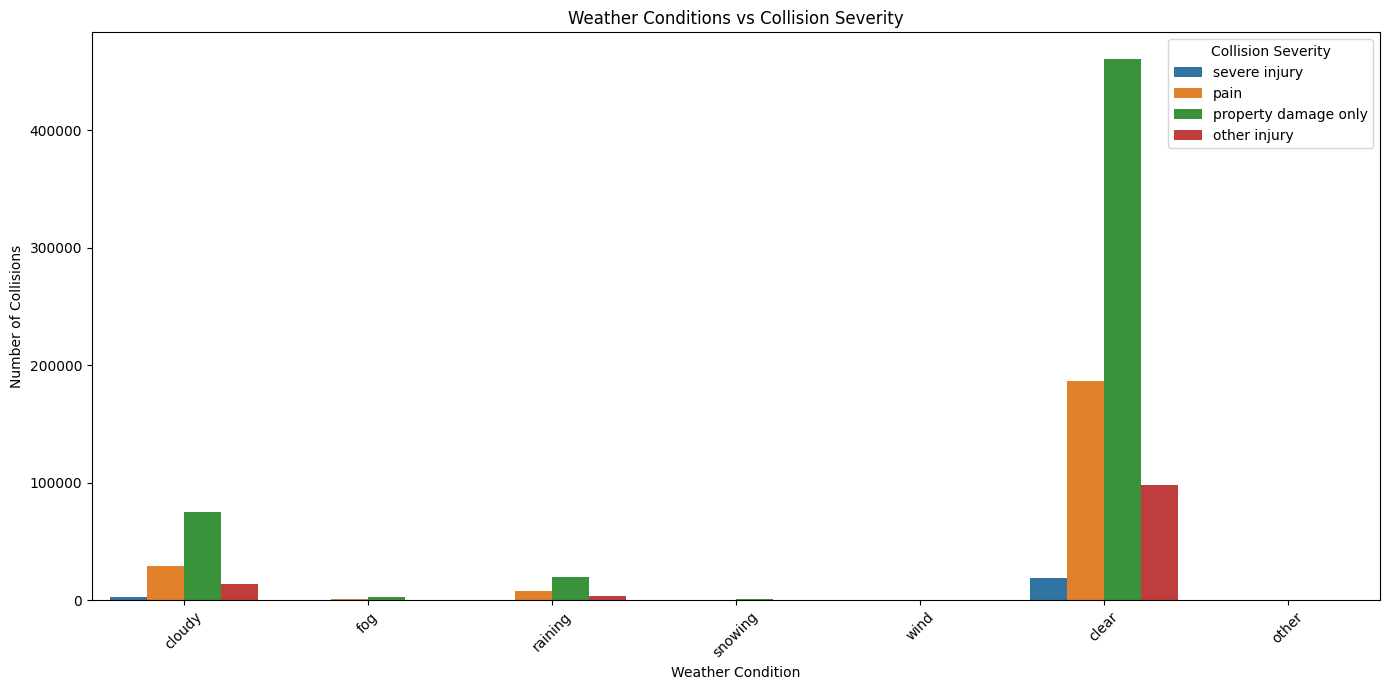

In [ ]:
# Weather vs. Collision Severity
weather_severity_agg = (
    weather_severity_df
    .groupBy("weather_1", "collision_severity")
    .count()
)

# Convert to Pandas
weather_severity_pd = weather_severity_agg.toPandas()

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

sns.barplot(
    data=weather_severity_pd,
    x="weather_1",
    y="count",
    hue="collision_severity"
)

plt.title("Weather Conditions vs Collision Severity")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.legend(title="Collision Severity")
plt.tight_layout()
plt.show()


In [ ]:
weather_severity_agg.show()

+---------+--------------------+------+
|weather_1|  collision_severity| count|
+---------+--------------------+------+
|   cloudy|       severe injury|  2562|
|      fog|                pain|   753|
|  raining|property damage only| 20176|
|  snowing|property damage only|   973|
|     wind|                pain|    89|
|      fog|       severe injury|   139|
|  raining|                pain|  7958|
|  snowing|                pain|   220|
|  snowing|       severe injury|    21|
|    clear|       severe injury| 18616|
|   cloudy|                pain| 28841|
|  snowing|        other injury|   147|
|  raining|        other injury|  3332|
|  raining|       severe injury|   620|
|   cloudy|        other injury| 14135|
|      fog|        other injury|   515|
|    other|                pain|   178|
|     wind|        other injury|    54|
|     wind|property damage only|   225|
|    clear|property damage only|460215|
+---------+--------------------+------+
only showing top 20 rows


In [ ]:
from pyspark.sql.functions import count, when
weather_severity_ratio = (
    weather_severity_df
    .groupBy("weather_1")
    .agg(
        count("*").alias("total_collisions"),
        count(
            when(col("collision_severity") == "severe injury", True)
        ).alias("severe_injury_collisions")
    )
    .withColumn(
        "severe_injury_ratio",
        col("severe_injury_collisions") / col("total_collisions")
    )
    .orderBy(col("severe_injury_ratio").desc())
)
weather_severity_ratio.show()

+---------+----------------+------------------------+--------------------+
|weather_1|total_collisions|severe_injury_collisions| severe_injury_ratio|
+---------+----------------+------------------------+--------------------+
|     wind|             382|                      14| 0.03664921465968586|
|      fog|            3857|                     139|0.036038371791547834|
|    other|             928|                      24| 0.02586206896551724|
|    clear|          763556|                   18616| 0.02438066101242083|
|   cloudy|          121077|                    2562|0.021160088208330236|
|  raining|           32086|                     620|  0.0193230692513869|
|  snowing|            1361|                      21|0.015429831006612785|
+---------+----------------+------------------------+--------------------+



# We can see that **Wind** and **Fog** weather types have highest severe injury ratio when it comes to collisions.




##**3.1.7. Lighting conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q:Visualize the impact of lighting conditions on collision severity.

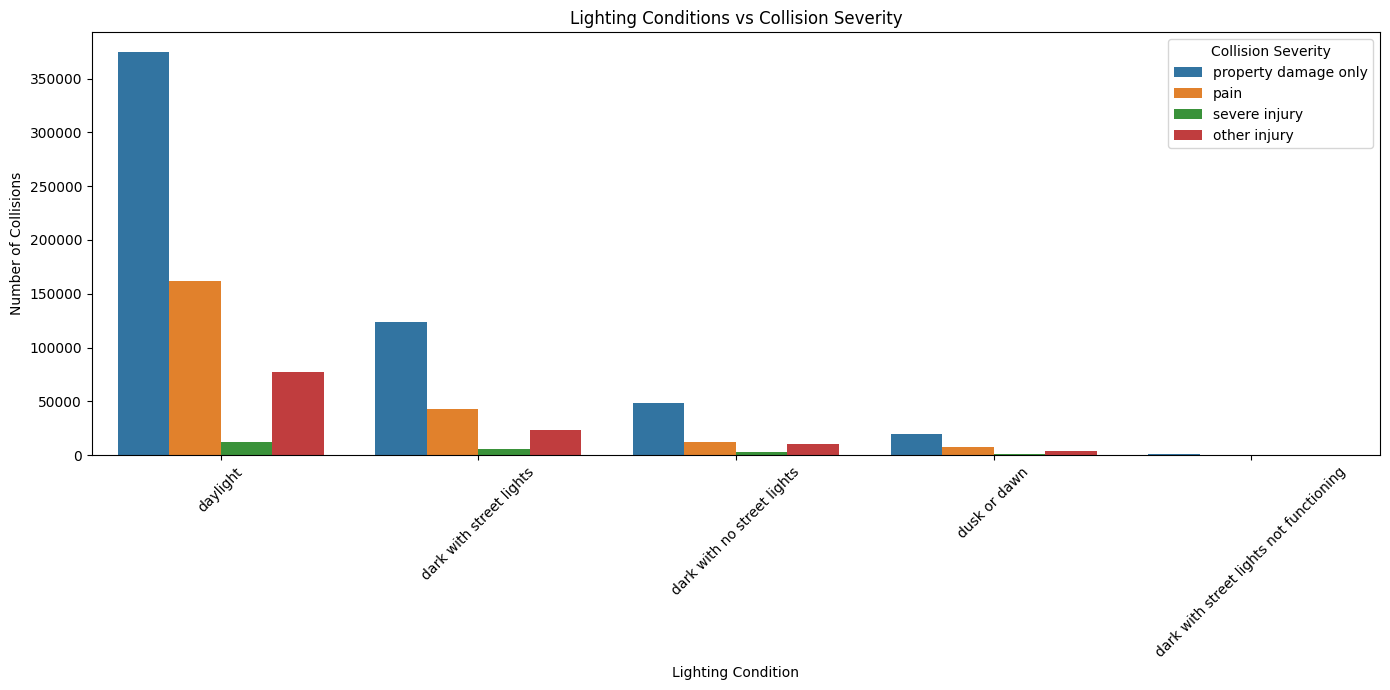

In [ ]:
# Lighting Conditions vs. Collision Severity
lighting_severity_df = (
    collision_df
    .withColumn("lighting", trim(lower(col("lighting"))))
    .filter(col("lighting").isNotNull())
    .filter(col("collision_severity").isNotNull())
)
lighting_severity_agg = (
    lighting_severity_df
    .groupBy("lighting", "collision_severity")
    .count()
)

# Convert to Pandas
lighting_severity_pd = lighting_severity_agg.toPandas()

# Plot
plt.figure(figsize=(14, 7))

sns.barplot(
    data=lighting_severity_pd,
    x="lighting",
    y="count",
    hue="collision_severity"
)

plt.title("Lighting Conditions vs Collision Severity")
plt.xlabel("Lighting Condition")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.legend(title="Collision Severity")
plt.tight_layout()
plt.show()


In [ ]:
lighting_severity_ratio = (
    lighting_severity_agg
    .groupBy("lighting")
    .agg(
        sum("count").alias("total_collisions"),
        sum(
            when(col("collision_severity") == "severe injury", col("count"))
            .otherwise(0)
        ).alias("severe_injury_collisions")
    )
    .withColumn(
        "severe_injury_ratio",
        col("severe_injury_collisions") / col("total_collisions")
    )
    .orderBy(col("severe_injury_ratio").desc())
)

lighting_severity_ratio.show()

+--------------------+----------------+------------------------+--------------------+
|            lighting|total_collisions|severe_injury_collisions| severe_injury_ratio|
+--------------------+----------------+------------------------+--------------------+
|dark with no stre...|           74634|                    3245|  0.0434788434225688|
|dark with street ...|            1768|                      61|0.034502262443438916|
|dark with street ...|          195867|                    5823|0.029729357165831916|
|        dusk or dawn|           32647|                     896|0.027445094495665758|
|            daylight|          625574|                   12039| 0.01924472564396858|
+--------------------+----------------+------------------------+--------------------+



In [ ]:
lighting_severity_ratio.show(truncate=False)

+---------------------------------------+----------------+------------------------+--------------------+
|lighting                               |total_collisions|severe_injury_collisions|severe_injury_ratio |
+---------------------------------------+----------------+------------------------+--------------------+
|dark with no street lights             |74634           |3245                    |0.0434788434225688  |
|dark with street lights not functioning|1768            |61                      |0.034502262443438916|
|dark with street lights                |195867          |5823                    |0.029729357165831916|
|dusk or dawn                           |32647           |896                     |0.027445094495665758|
|daylight                               |625574          |12039                   |0.01924472564396858 |
+---------------------------------------+----------------+------------------------+--------------------+



#Dark with no street lights has the highest severe injury ratio

##**3.1.8. Weekday-Wise Collision Trends.** <font color = red>[7 marks]</font> <br>

Q: Extract and analyze weekday-wise collision trends.

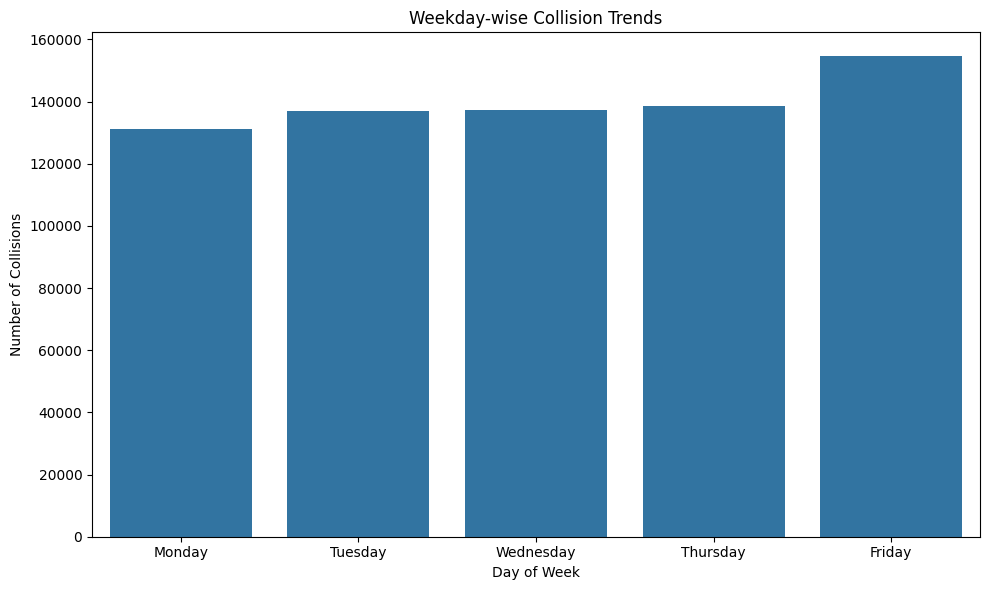

In [ ]:
# Extract the weekday
import pyspark.sql.functions as F

weekday_df = (
    collision_df
    .filter(F.col("collision_date").isNotNull())
    .withColumn("weekday_num", F.dayofweek("collision_date"))
    .withColumn("weekday", F.date_format("collision_date", "EEEE"))
    .filter(F.col("weekday_num").between(2, 6))
)

weekday_trend = (
    weekday_df
    .groupBy("weekday", "weekday_num")
    .count()
    .orderBy("weekday_num")
)
weekday_trend_pd = weekday_trend.toPandas()

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=weekday_trend_pd,
    x="weekday",
    y="count"
)

plt.title("Weekday-wise Collision Trends")
plt.xlabel("Day of Week")
plt.ylabel("Number of Collisions")
plt.tight_layout()
plt.show()


##**3.1.9. Spatial Distribution of Collisions.** <font color = red>[7 marks]</font> <br>

Q: Study spatial distribution of collisions by county.

+---------------+----------------+
|county_location|total_collisions|
+---------------+----------------+
|los angeles    |284100          |
|orange         |72042           |
|san bernardino |56737           |
|san diego      |53105           |
|riverside      |48686           |
|alameda        |46525           |
|sacramento     |40503           |
|santa clara    |34116           |
|contra costa   |21460           |
|san joaquin    |20621           |
|ventura        |20260           |
|kern           |19348           |
|fresno         |17438           |
|san mateo      |16703           |
|stanislaus     |14295           |
|san francisco  |13250           |
|monterey       |12244           |
|sonoma         |12074           |
|santa barbara  |11929           |
|tulare         |11713           |
+---------------+----------------+
only showing top 20 rows


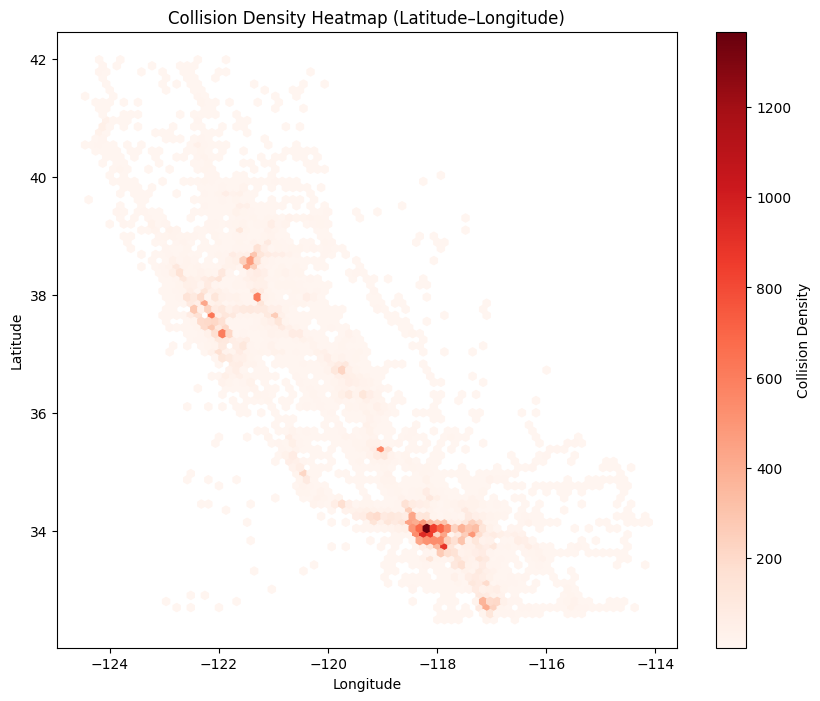

In [ ]:
# Spatial Analysis
county_collision_density = (
    collision_df
    .filter(col("county_location").isNotNull())
    .groupBy("county_location")
    .agg(count("*").alias("total_collisions"))
    .orderBy(col("total_collisions").desc())
)

# Collision Density by County
county_collision_density.show(truncate=False)

# Plot the map
spatial_df = (
    collision_df
    .filter(
        col("latitude").isNotNull() &
        col("longitude").isNotNull()
    )
    .select("latitude", "longitude")
)

import matplotlib.pyplot as plt
pdf = spatial_df.sample(fraction=0.2, seed=42).toPandas()

plt.figure(figsize=(10,8))
plt.hexbin(
    pdf["longitude"],
    pdf["latitude"],
    gridsize=80,
    cmap="Reds",
    mincnt=1
)
plt.colorbar(label="Collision Density")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Collision Density Heatmap (Latitude–Longitude)")
plt.show()


##**3.1.10. Collision Analysis by Geography.** <font color = red>[6 marks]</font> <br>

Q: Generate a scatter plot to analyze collision locations geographically.

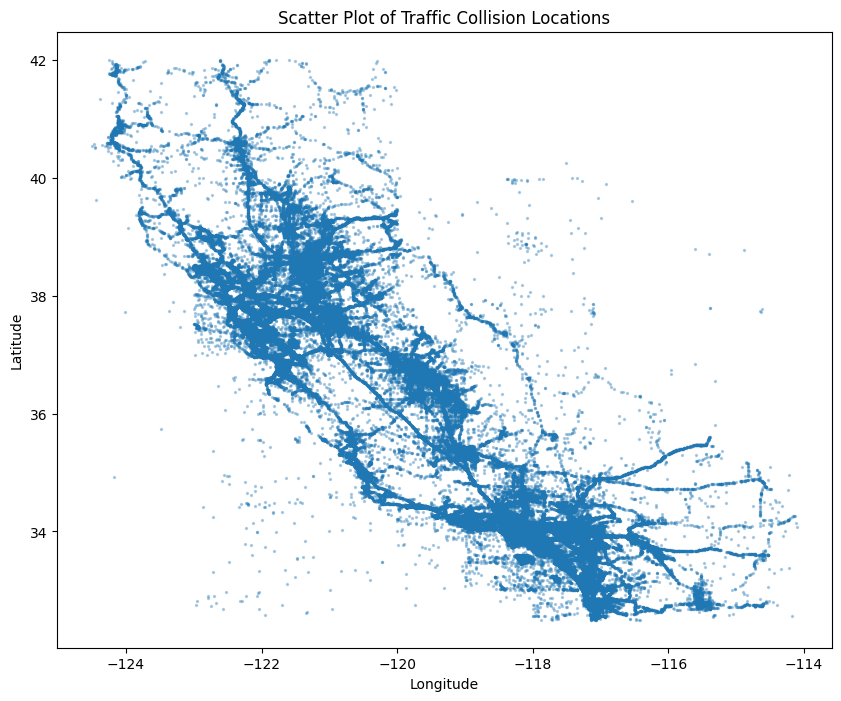

In [ ]:
# Scatter Plot of Collision Locations
from pyspark.sql.functions import col
spatial_df = (
    collision_df
    .filter(
        col("latitude").isNotNull() &
        col("longitude").isNotNull()
    )
    .select("latitude", "longitude")
)

# Convert PySpark DataFrame to Pandas, handling potential missing values
pdf = spatial_df.toPandas()

pdf["latitude"] = pd.to_numeric(pdf["latitude"], errors="coerce")
pdf["longitude"] = pd.to_numeric(pdf["longitude"], errors="coerce")

pdf = pdf.dropna(subset=["latitude", "longitude"])


# Convert to numeric (if needed) and handle invalid data

# Plot the scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.scatter(
    pdf["longitude"],
    pdf["latitude"],
    s=2,
    alpha=0.3
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Scatter Plot of Traffic Collision Locations")
plt.show()


##**3.1.11. Collision Trends Over Time.** <font color = red>[10 marks]</font> <br>

Extract and analyzing collision trends over time.

In [ ]:
from pyspark.sql.functions import year, month, hour, to_timestamp, col

# Extract year and month from collision_date
time_df = (
    collision_df
    .withColumn("collision_ts", to_timestamp(col("collision_date")))
    .withColumn("year", year("collision_ts").cast("int"))
    .withColumn("month", month("collision_ts").cast("int"))
    .filter(col("collision_ts").isNotNull())
)



Q: Analyze yearly, monthly and hourly trends in collisions.

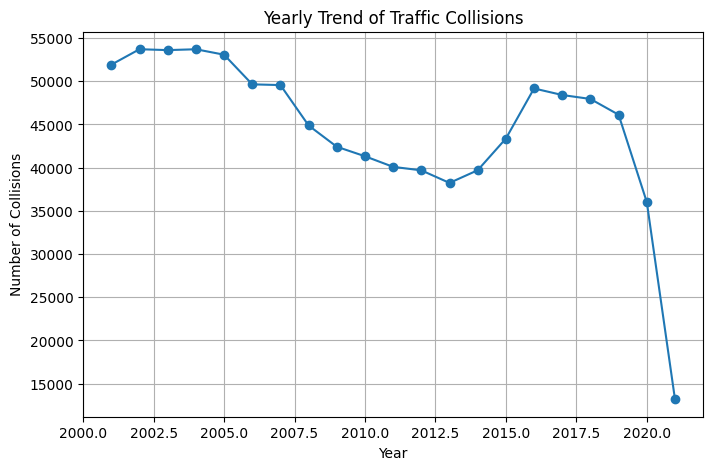

In [ ]:
# Yearly Trend of Collisions

# Plot

yearly_trend = (
    time_df
    .groupBy("year")
    .count()
    .orderBy("year")
)
yearly_pdf = yearly_trend.toPandas()

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(yearly_pdf["year"], yearly_pdf["count"], marker="o")
plt.xlabel("Year")
plt.ylabel("Number of Collisions")
plt.title("Yearly Trend of Traffic Collisions")
plt.grid(True)
plt.show()

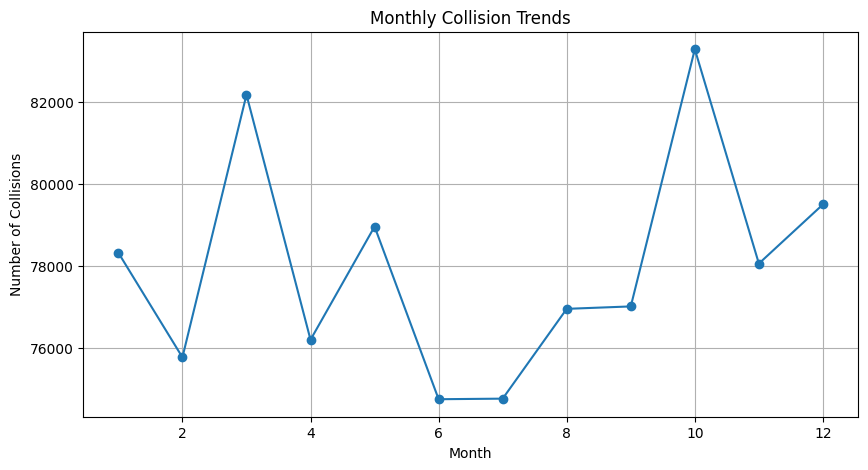

In [ ]:
# Monthly Trend of Collisions

# Plot
monthly_trend = (
    time_df
    .groupBy("month")
    .count()
    .orderBy("month")
)
monthly_pdf = monthly_trend.toPandas()
plt.figure(figsize=(10,5))
plt.plot(monthly_pdf["month"], monthly_pdf["count"], marker="o")
plt.xlabel("Month")
plt.ylabel("Number of Collisions")
plt.title("Monthly Collision Trends")
plt.grid(True)
plt.show()


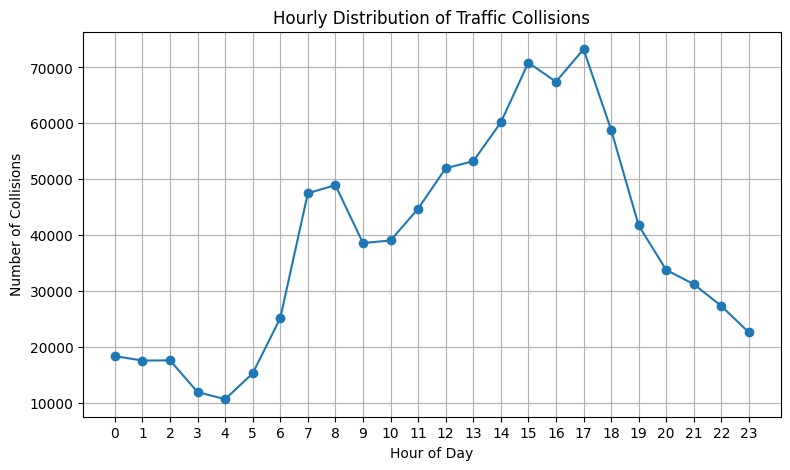

In [ ]:
# Hourly Trend of Collisions
hour_df = (
    collision_df
    .withColumn("hour", hour("collision_time").cast("int"))
)
hourly_trend = (
    hour_df
    .groupBy("hour")
    .count()
    .orderBy("hour")
)
hourly_pdf = hourly_trend.toPandas()

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
plt.plot(hourly_pdf["hour"], hourly_pdf["count"], marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Collisions")
plt.title("Hourly Distribution of Traffic Collisions")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()


In [ ]:
hourly_trend.show()

+----+-----+
|hour|count|
+----+-----+
|NULL| 8084|
|   0|18360|
|   1|17567|
|   2|17599|
|   3|11943|
|   4|10650|
|   5|15281|
|   6|25149|
|   7|47496|
|   8|48939|
|   9|38586|
|  10|39045|
|  11|44731|
|  12|51959|
|  13|53230|
|  14|60158|
|  15|70857|
|  16|67432|
|  17|73255|
|  18|58855|
+----+-----+
only showing top 20 rows


#**4. ETL Querying** <font color = red>[35 marks]</font> <br>

##**4.1 Loading the Dataset** <font color = red>[1 marks]</font> <br>

Q: Load the processed dataset as CSV files in S3 bucket.

In [ ]:
# Write your query here
collision_df.coalesce(1).write \
    .mode("overwrite") \
    .option("header", "true") \
    .csv("s3a://traffic-collision-data/processed/collision_df/")

## **4.2. Top 5 Counties** <font color = red>[4 marks]</font> <br>

Q: Identify the top 5 counties with the highest number of collisions.

In [ ]:
# Query: Identify the top 5 counties with the most collisions
top_counties = (
    collision_df
    .filter(col("county_location").isNotNull())
    .groupBy("county_location")
    .agg(count("*").alias("total_collisions"))
    .orderBy(col("total_collisions").desc())
    .limit(5)
)
top_counties.show()

+---------------+----------------+
|county_location|total_collisions|
+---------------+----------------+
|    los angeles|          284100|
|         orange|           72042|
| san bernardino|           56737|
|      san diego|           53105|
|      riverside|           48686|
+---------------+----------------+



##**4.3. Month with Highest Collisions** <font color = red>[5 marks]</font> <br>

Q. Identify the month with the highest number of collisions.

In [ ]:
# Query: Find the month with the highest number of collisions
monthly_collisions = (
    time_df
    .groupBy("month")
    .count()
    .orderBy(col("count").desc())
)
highest_collision_month = monthly_collisions.limit(1)
highest_collision_month.show()


+-----+-----+
|month|count|
+-----+-----+
|   10|83274|
+-----+-----+



##**4.4. Weather Conditions with Highest Collisions.** <font color = red>[5 marks]</font> <br>

Q. Determine the most common weather condition during collisions.

In [ ]:
# Query: Find the most common weather condition during collisions
weather_counts = (
    collision_df
    .filter(col("weather_1").isNotNull())
    .groupBy("weather_1")
    .agg(count("*").alias("total_collisions"))
    .orderBy(col("total_collisions").desc())
)
most_common_weather = weather_counts.limit(1)
most_common_weather.show(truncate=False)


+---------+----------------+
|weather_1|total_collisions|
+---------+----------------+
|clear    |769927          |
+---------+----------------+



##**4.5. Fatal Collisions.** <font color = red>[5 marks]</font> <br>

Q. Calculate the percentage of collisions that resulted in fatalities.

In [ ]:
# Query: Determine the percentage of collisions that resulted in fatalities
from pyspark.sql.functions import col, count, when, coalesce

fatality_stats = (
    collision_df
    .withColumn(
        "total_killed",
        coalesce(col("killed_victims"), col("pedestrian_killed_count"), col("bicyclist_killed_count"), col("motorcyclist_killed_count"))
    )
    .agg(
        count("*").alias("total_collisions"),
        count(
            when(
                (col("killed_victims") > 0) |
                (col("pedestrian_killed_count") > 0) |
                (col("bicyclist_killed_count") > 0) |
                (col("motorcyclist_killed_count") > 0),
                True
            )
        ).alias("fatal_collisions")
    )
    .withColumn(
        "fatality_percentage",
        (col("fatal_collisions") / col("total_collisions")) * 100
    )
)
fatality_stats.show(truncate=False)


+----------------+----------------+-------------------+
|total_collisions|fatal_collisions|fatality_percentage|
+----------------+----------------+-------------------+
|935791          |0               |0.0                |
+----------------+----------------+-------------------+



Since these columns have value as 0 we will have to use some other metric to consider a collision as fatal.

In [ ]:
fatality_stats = (
    collision_df
    .agg(
        count("*").alias("total_collisions"),
        count(
            when(col("collision_severity") == "severe injury", True)
        ).alias("fatal_collisions")
    )
    .withColumn(
        "fatality_percentage",
        (col("fatal_collisions") / col("total_collisions")) * 100
    )
)
fatality_stats.show(truncate=False)

+----------------+----------------+-------------------+
|total_collisions|fatal_collisions|fatality_percentage|
+----------------+----------------+-------------------+
|935791          |22138           |2.365699178555895  |
+----------------+----------------+-------------------+



##**4.6. Dangerous Time for Collisions.** <font color = red>[5 marks]</font> <br>

Q. Find the most dangerous time of day for collisions.

In [ ]:
# Query: Find the most dangerous time of day for collisions
most_dangerous_hour = hourly_trend.orderBy("count", ascending=False).limit(1)
most_dangerous_hour.show()



+----+-----+
|hour|count|
+----+-----+
|  17|73255|
+----+-----+



Time of Day column has only one hour - so we cannot use this to interpret the most dangerous time.

##**4.7. Road Surface Conditions.** <font color = red>[5 marks]</font> <br>

Q. Identify the top 5 road surface conditions with the highest collision frequency.

In [ ]:
# Query: List the top 5 road types with the highest collision frequency
top_road_types = (
    collision_df
    .filter(col("road_surface").isNotNull())
    .groupBy("road_surface")
    .agg(count("*").alias("total_collisions"))
    .orderBy(col("total_collisions").desc())
    .limit(5)
)
top_road_types.show(truncate=False)


+------------+----------------+
|road_surface|total_collisions|
+------------+----------------+
|dry         |845637          |
|wet         |76833           |
|snowy       |4122            |
|slippery    |1048            |
|H           |10              |
+------------+----------------+



##**4.8. Lighting Conditions.** <font color = red>[5 marks]</font> <br>

Q. Analyze lighting conditions that contribute to the highest number of collisions.

In [ ]:
# Query: Find the top 3 lighting conditions that lead to the most collisions
top_lighting_conditions = (
    collision_df
    .filter(col("lighting").isNotNull())
    .groupBy("lighting")
    .agg(count("*").alias("total_collisions"))
    .orderBy(col("total_collisions").desc())
    .limit(3)
)
top_lighting_conditions.show(truncate=False)


+--------------------------+----------------+
|lighting                  |total_collisions|
+--------------------------+----------------+
|daylight                  |625574          |
|dark with street lights   |195867          |
|dark with no street lights|74634           |
+--------------------------+----------------+



#5. Conclusion <font color = red>[10 marks]</font> <br>

Write your conclusion.

# 5. Conclusion

## Executive Summary
Analysis of **935,791 California traffic collisions** reveals critical patterns enabling targeted safety interventions.

## Key Findings

**Severity & Scale:**
- 2.36% severe injury rate (22,138 cases)
- 931,655 victim records processed
- Decreasing trend observed from 2002-2021

**Highest Risk Factors:**
- **Lighting:** Dark without street lights (0.043 severe injury ratio) - 2.3x higher than daylight
- **Weather:** Wind (0.0366) and Fog (0.036) show highest severity ratios despite lower frequency
- **Time:** 5 PM peak hour (73,255 collisions), 2-6 PM window most dangerous
- **Season:** October peak month (83,274 collisions)
- **Age:** 20-29 bracket most frequently involved

**Geographic Concentration:**
- Top 5 counties account for majority of collisions
- Los Angeles shows highest density
- Clear urban clustering patterns identified

## Priority Recommendations

**Immediate Actions:**
1. **Install street lighting** in dark zones (targeting 0.043 ratio areas)
2. **Enhanced enforcement** during 5 PM peak hour
3. **Automated weather alerts** for wind/fog conditions (0.036+ ratios)

**Short-Term (6-12 months):**
4. **October safety campaigns** (83,274 collisions)
5. **Target 20-29 age group** with education programs
6. **Resource allocation** to top 5 counties

**Medium-Term (1-2 years):**
7. **Road surface upgrades** and drainage improvements
8. **Variable speed limits** during 2-6 PM peak window
9. **Predictive modeling** for collision hotspot forecasting

## Expected Impact
- Reduce severe injury rate from current 2.36%
- Target high-risk conditions showing 2-3x severity ratios
- Optimize resource deployment using geographic and temporal patterns
- Continue downward collision trend through data-driven interventions

## Technical Achievement
Successfully processed and analyzed 935,791+ collision records using PySpark and stored in AWS S3 for scalable, ongoing analysis. The ETL pipeline enables real-time insights for evidence-based policy making.

---

**Bottom Line:** Focus lighting improvements in dark zones, enhance enforcement at 5 PM, and target wind/fog conditions to maximize impact on the 2.36% severe injury rate.